# Breast Cancer Detection — Advanced Multi-Task EfficientNet-B0

## Objective

Build an image-based breast cancer screening model using:

- EfficientNet-B0 pretrained backbone
- 768 × 768 image resolution
- Multi-task learning
- Cancer classification
- Breast density classification
- Mammogram view classification
- Laterality classification
- Patient-level train/validation/test split
- ~10% positive sampling
- Grad-CAM explainability
- Model-derived POI localization
- Breast-level prediction aggregation

The final model should support image-only inference and produce:

- Cancer / No Cancer
- Cancer confidence
- Density
- View
- Laterality
- Grad-CAM / POI visualization

# 1. Import Libraries

Import all libraries required for:

- Data processing
- Visualization
- Image preprocessing
- PyTorch modeling
- Evaluation
- Grad-CAM

In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import models, transforms

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
CUDA Available: True


# 2. Reproducibility and Device

Set random seeds and select the available computation device.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


# 3. Dataset Paths

Define the paths for:

- Original RSNA metadata
- Remek processed mammogram images

In [3]:
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

print("Kaggle input exists:", KAGGLE_INPUT.exists())

if KAGGLE_INPUT.exists():
    for item in sorted(KAGGLE_INPUT.iterdir()):
        print(item)

Kaggle input exists: True
/kaggle/input/rsna-breast-cancer-detection
/kaggle/input/rsna-breast-cancer-detection-poi-images


In [4]:
from pathlib import Path

# =========================
# Dataset Paths
# =========================

RSNA_BASE = Path("/kaggle/input/rsna-breast-cancer-detection")
POI_BASE = Path("/kaggle/input/rsna-breast-cancer-detection-poi-images")

IMAGE_DIR = POI_BASE / "bc_1280_train_lut"

print("RSNA base:", RSNA_BASE)
print("POI base:", POI_BASE)
print("Image directory:", IMAGE_DIR)

print("\nExists:")
print("RSNA:", RSNA_BASE.exists())
print("POI:", POI_BASE.exists())
print("Images:", IMAGE_DIR.exists())

RSNA base: /kaggle/input/rsna-breast-cancer-detection
POI base: /kaggle/input/rsna-breast-cancer-detection-poi-images
Image directory: /kaggle/input/rsna-breast-cancer-detection-poi-images/bc_1280_train_lut

Exists:
RSNA: True
POI: True
Images: True


In [5]:
TRAIN_CSV = "/kaggle/input/rsna-breast-cancer-detection/train.csv"

df = pd.read_csv(TRAIN_CSV)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (54706, 14)

Columns:
['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case']


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


# 5. Dataset Information

Check:

- Number of rows
- Number of patients
- Number of images
- Data types
- Basic statistics

In [6]:
print("Rows:", len(df))
print("Unique Patients:", df["patient_id"].nunique())
print("Unique Images:", df["image_id"].nunique())

print("\nData Types:")
display(df.dtypes)

print("\nNumerical Summary:")
display(df.describe(include="all").T)

Rows: 54706
Unique Patients: 11913
Unique Images: 54706

Data Types:


site_id                      int64
patient_id                   int64
image_id                     int64
laterality                  object
view                        object
age                        float64
cancer                       int64
biopsy                       int64
invasive                     int64
BIRADS                     float64
implant                      int64
density                     object
machine_id                   int64
difficult_negative_case       bool
dtype: object


Numerical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
site_id,54706.0,NaN,NaN,NaN,1.460407,0.498434,1.0,1.0,1.0,2.0,2.0
patient_id,54706.0,NaN,NaN,NaN,32698.865262,18893.861534,5.0,16481.0,32432.0,48999.0,65534.0
image_id,54706.0,NaN,NaN,NaN,1079385987.6785,618326916.930432,68491.0,545815331.75,1082688510.5,1613227667.5,2147471846.0
laterality,54706,2,R,27439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
view,54706,6,MLO,27903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,54669.0,NaN,NaN,NaN,58.543928,10.050884,26.0,51.0,59.0,66.0,89.0
cancer,54706.0,NaN,NaN,NaN,0.021168,0.143944,0.0,0.0,0.0,0.0,1.0
biopsy,54706.0,NaN,NaN,NaN,0.054272,0.226556,0.0,0.0,0.0,0.0,1.0
invasive,54706.0,NaN,NaN,NaN,0.014953,0.121365,0.0,0.0,0.0,0.0,1.0
BIRADS,26286.0,NaN,NaN,NaN,0.77235,0.590062,0.0,0.0,1.0,1.0,2.0


# 6. Missing Values Analysis

Analyze missing values before modeling.

In [7]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    )
}).sort_values(
    "Missing Count",
    ascending=False
)

display(missing_df)

,Missing Count,Missing Percentage
BIRADS,28420,51.950426
density,25236,46.130223
age,37,0.067634
image_id,0,0.000000
patient_id,0,0.000000
site_id,0,0.000000
view,0,0.000000
laterality,0,0.000000
biopsy,0,0.000000
cancer,0,0.000000


# 7. Duplicate Analysis

Check duplicate rows and duplicate patient-image combinations.

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

duplicate_ids = df.duplicated(
    subset=["patient_id", "image_id"]
).sum()

print(
    "Duplicate patient-image pairs:",
    duplicate_ids
)

Duplicate Rows: 0
Duplicate patient-image pairs: 0


# 8. Cancer Distribution

Analyze the severe class imbalance in the Cancer target.

In [9]:
cancer_counts = df["cancer"].value_counts().sort_index()

print(cancer_counts)

print("\nCancer Percentage:")
print(
    (df["cancer"].value_counts(normalize=True) * 100)
    .round(2)
)

cancer
0    53548
1     1158
Name: count, dtype: int64

Cancer Percentage:
cancer
0    97.88
1     2.12
Name: proportion, dtype: float64


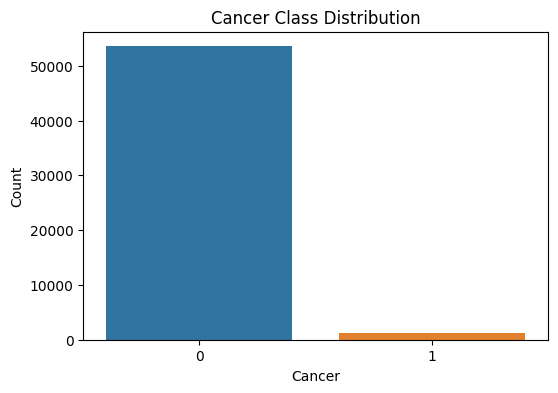

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="cancer"
)

plt.title("Cancer Class Distribution")
plt.xlabel("Cancer")
plt.ylabel("Count")

plt.show()

# 9. Categorical Feature Analysis

Analyze:

- Density
- View
- Laterality

In [11]:
for col in ["density", "view", "laterality"]:
    print(f"\n===== {col.upper()} =====")
    display(df[col].value_counts(dropna=False))


===== DENSITY =====


density
NaN    25236
B      12651
C      12175
A       3105
D       1539
Name: count, dtype: int64


===== VIEW =====


view
MLO    27903
CC     26765
AT        19
LM        10
ML         8
LMO        1
Name: count, dtype: int64


===== LATERALITY =====


laterality
R    27439
L    27267
Name: count, dtype: int64

# 10. Age Analysis

In [12]:
print("Minimum Age:", df["age"].min())
print("Maximum Age:", df["age"].max())
print("Mean Age:", df["age"].mean())
print("Median Age:", df["age"].median())

Minimum Age: 26.0
Maximum Age: 89.0
Mean Age: 58.54392800307304
Median Age: 59.0


# 11. Build Image Paths

Match each RSNA image ID with its corresponding Remek image.

In [13]:
image_files = list(IMAGE_DIR.glob("*.png"))

image_map = {
    p.stem.split("_")[1]: str(p)
    for p in image_files
}

print("Images Found:", len(image_files))

Images Found: 54706


In [14]:
df["image_path"] = df["image_id"].astype(str).map(image_map)

print(
    "Missing Image Paths:",
    df["image_path"].isna().sum()
)

df.head()

Missing Image Paths: 0


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,image_path
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False,/kaggle/input/rsna-breast-cancer-detection-poi...
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False,/kaggle/input/rsna-breast-cancer-detection-poi...
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False,/kaggle/input/rsna-breast-cancer-detection-poi...
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False,/kaggle/input/rsna-breast-cancer-detection-poi...
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True,/kaggle/input/rsna-breast-cancer-detection-poi...


# 12. Image Availability Check

Keep only records for which the corresponding mammogram image exists.

In [15]:
model_df = df.dropna(
    subset=["image_path"]
).copy()

model_df.reset_index(drop=True, inplace=True)

print("Model Dataset Shape:", model_df.shape)

Model Dataset Shape: (54706, 15)


# 13. Patient-Level Train / Validation / Test Split

Split the dataset at the patient level to prevent data leakage.

All images belonging to the same patient must remain inside
the same split.

In [16]:
patient_labels = (
    model_df
    .groupby("patient_id")["cancer"]
    .max()
    .reset_index()
)

train_patients, temp_patients = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["cancer"],
    random_state=SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    stratify=temp_patients["cancer"],
    random_state=SEED
)

train_patient_ids = train_patients["patient_id"].values
val_patient_ids = val_patients["patient_id"].values
test_patient_ids = test_patients["patient_id"].values

# 14. Create Train, Validation and Test DataFrames

In [17]:
train_df = model_df[
    model_df["patient_id"].isin(train_patient_ids)
].copy()

val_df = model_df[
    model_df["patient_id"].isin(val_patient_ids)
].copy()

test_df = model_df[
    model_df["patient_id"].isin(test_patient_ids)
].copy()

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (38341, 15)
Validation: (8184, 15)
Test: (8181, 15)


# 15. Patient Leakage Check

Verify that no patient appears in more than one split.

In [18]:
train_ids = set(train_df["patient_id"])
val_ids = set(val_df["patient_id"])
test_ids = set(test_df["patient_id"])

print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


# 16. Split Distribution

Compare Cancer distribution across Train, Validation and Test.

In [19]:
for name, split in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n===== {name} =====")
    print("Images:", len(split))
    print("Patients:", split["patient_id"].nunique())
    print(
        split["cancer"]
        .value_counts()
        .sort_index()
    )
    print(
        "Positive Ratio:",
        round(split["cancer"].mean() * 100, 2),
        "%"
    )


===== Train =====
Images: 38341
Patients: 8339
cancer
0    37540
1      801
Name: count, dtype: int64
Positive Ratio: 2.09 %

===== Validation =====
Images: 8184
Patients: 1787
cancer
0    8004
1     180
Name: count, dtype: int64
Positive Ratio: 2.2 %

===== Test =====
Images: 8181
Patients: 1787
cancer
0    8004
1     177
Name: count, dtype: int64
Positive Ratio: 2.16 %


# 17. Mammogram Image Inspection

Inspect image dimensions and pixel values.

In [20]:
sample_path = train_df.iloc[0]["image_path"]

sample_image = Image.open(sample_path)

print("Image Size:", sample_image.size)
print("Mode:", sample_image.mode)

image_array = np.array(sample_image)

print("Shape:", image_array.shape)
print("Dtype:", image_array.dtype)
print("Min:", image_array.min())
print("Max:", image_array.max())

Image Size: (450, 1280)
Mode: L
Shape: (1280, 450)
Dtype: uint8
Min: 0
Max: 252


# 18. Sample Mammograms

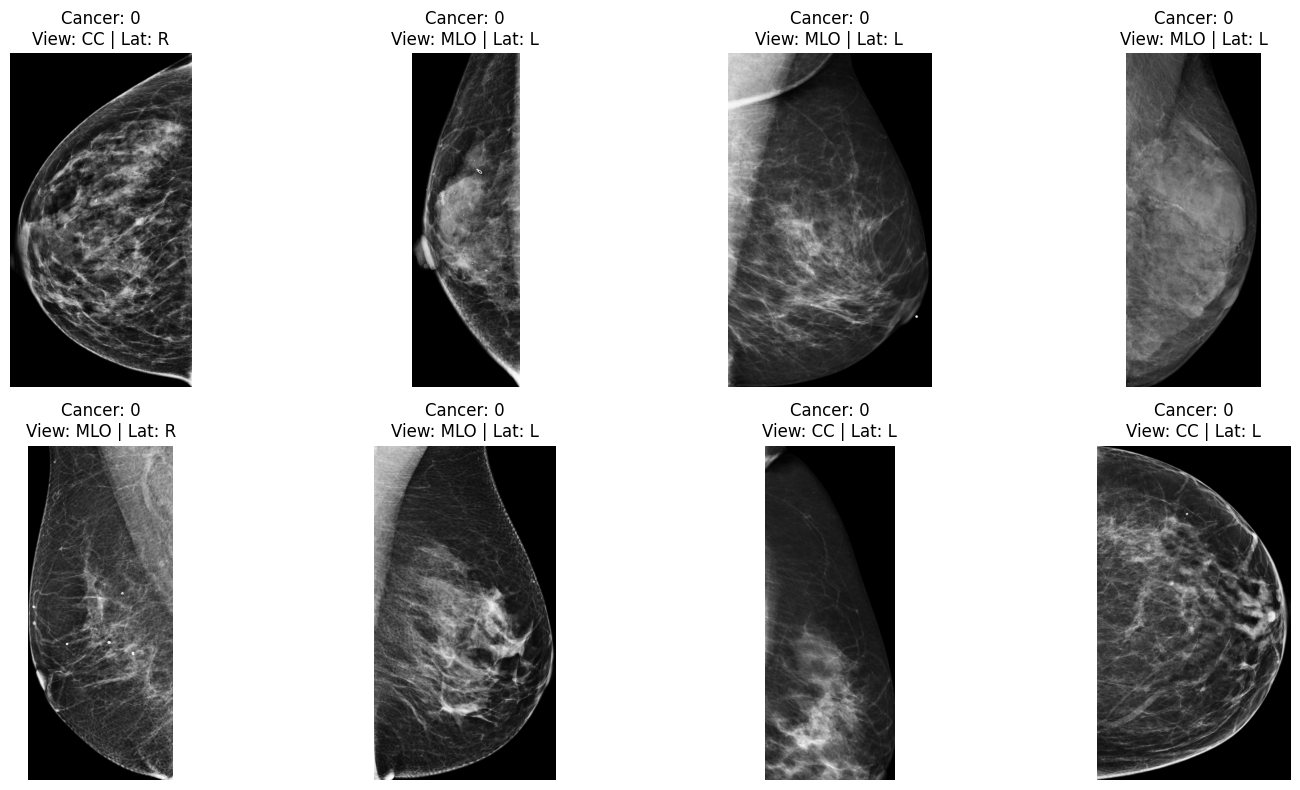

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

sample_rows = train_df.sample(
    8,
    random_state=SEED
)

for ax, (_, row) in zip(
    axes.flat,
    sample_rows.iterrows()
):
    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    ax.imshow(image)
    ax.set_title(
        f"Cancer: {row['cancer']}\n"
        f"View: {row['view']} | "
        f"Lat: {row['laterality']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# 19. Encode Multi-Task Labels

Create label encoders for:

- Density
- View
- Laterality

Missing Density values will be ignored during the Density loss.

In [22]:
label_encoders = {}

for task in ["density", "view", "laterality"]:

    encoder = LabelEncoder()

    values = train_df[task].dropna().astype(str)

    encoder.fit(values)

    label_encoders[task] = encoder

    print(
        task,
        "classes:",
        encoder.classes_
    )

density classes: ['A' 'B' 'C' 'D']
view classes: ['AT' 'CC' 'LM' 'LMO' 'ML' 'MLO']
laterality classes: ['L' 'R']


# 20. Image Preprocessing and Data Augmentation

Use 768 × 768 input resolution.

Training augmentation includes:

- Random Rotation
- Random Affine
- Mild ColorJitter

Horizontal Flip is intentionally NOT used because Laterality
is one of the prediction targets.

In [23]:
IMAGE_SIZE = 768

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


class SquarePad:

    def __call__(self, image):

        w, h = image.size

        size = max(w, h)

        left = (size - w) // 2
        top = (size - h) // 2

        right = size - w - left
        bottom = size - h - top

        return transforms.functional.pad(
            image,
            (
                left,
                top,
                right,
                bottom
            ),
            fill=0
        )

In [24]:
train_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),

    SquarePad(),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.90, 1.10)
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

In [25]:
val_test_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),

    SquarePad(),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

# 21. Multi-Task Mammogram Dataset

In [26]:
class MultiTaskMammogramDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):
        return len(self.df)

    def encode(
        self,
        task,
        value
    ):

        if pd.isna(value):
            return -1

        return int(
            label_encoders[task]
            .transform([str(value)])[0]
        )

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return {

            "image": image,

            "patient_id": str(
                row["patient_id"]
            ),

            "image_id": str(
                row["image_id"]
            ),

            "laterality_raw": str(
                row["laterality"]
            ),

            "view_raw": str(
                row["view"]
            ),

            "cancer": torch.tensor(
                float(row["cancer"]),
                dtype=torch.float32
            ),

            "density": torch.tensor(
                self.encode(
                    "density",
                    row["density"]
                ),
                dtype=torch.long
            ),

            "view": torch.tensor(
                self.encode(
                    "view",
                    row["view"]
                ),
                dtype=torch.long
            ),

            "laterality": torch.tensor(
                self.encode(
                    "laterality",
                    row["laterality"]
                ),
                dtype=torch.long
            )
        }

# 22. Create Dataset Objects

In [27]:
train_dataset = MultiTaskMammogramDataset(
    train_df,
    transform=train_transform
)

val_dataset = MultiTaskMammogramDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = MultiTaskMammogramDataset(
    test_df,
    transform=val_test_transform
)

print("Train Dataset:", len(train_dataset))
print("Validation Dataset:", len(val_dataset))
print("Test Dataset:", len(test_dataset))

Train Dataset: 38341
Validation Dataset: 8184
Test Dataset: 8181


# 23. WeightedRandomSampler — 10% Positive Sampling

The original dataset contains approximately 2% Cancer images.

Instead of forcing a very high positive sampling ratio,
we target approximately 10% positive samples per training epoch.

This is intentionally less aggressive than the previous
25% sampling strategy.

In [28]:
train_labels = (
    train_df["cancer"]
    .astype(int)
    .values
)

n_pos = int(
    (train_labels == 1).sum()
)

n_neg = int(
    (train_labels == 0).sum()
)

TARGET_POSITIVE_RATIO = 0.10

pos_sample_weight = (
    TARGET_POSITIVE_RATIO / n_pos
)

neg_sample_weight = (
    (1 - TARGET_POSITIVE_RATIO) / n_neg
)

sample_weights = np.where(
    train_labels == 1,
    pos_sample_weight,
    neg_sample_weight
)

sampler = WeightedRandomSampler(
    weights=torch.as_tensor(
        sample_weights,
        dtype=torch.double
    ),
    num_samples=len(train_dataset),
    replacement=True
)

print("Negative:", n_neg)
print("Positive:", n_pos)
print(
    "Target Positive Ratio:",
    TARGET_POSITIVE_RATIO
)

Negative: 37540
Positive: 801
Target Positive Ratio: 0.1


# 24. DataLoaders

In [29]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


# 25. Multi-Task EfficientNet-B0

The model contains one shared EfficientNet-B0 backbone with
four prediction heads:

- Cancer
- Density
- View
- Laterality

In [30]:
class MultiTaskEfficientNetB0(nn.Module):

    def __init__(
        self,
        density_classes,
        view_classes,
        laterality_classes
    ):

        super().__init__()

        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        feature_dim = (
            self.backbone
            .classifier[1]
            .in_features
        )

        self.backbone.classifier = nn.Identity()

        self.cancer_head = nn.Sequential(
            nn.Dropout(0.40),
            nn.Linear(
                feature_dim,
                1
            )
        )

        self.density_head = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(
                feature_dim,
                density_classes
            )
        )

        self.view_head = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(
                feature_dim,
                view_classes
            )
        )

        self.laterality_head = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(
                feature_dim,
                laterality_classes
            )
        )

    def forward(self, image):

        features = self.backbone(
            image
        )

        return {

            "cancer":
                self.cancer_head(features),

            "density":
                self.density_head(features),

            "view":
                self.view_head(features),

            "laterality":
                self.laterality_head(features)
        }

# 26. Initialize Model

In [31]:
model = MultiTaskEfficientNetB0(

    density_classes=len(
        label_encoders["density"]
        .classes_
    ),

    view_classes=len(
        label_encoders["view"]
        .classes_
    ),

    laterality_classes=len(
        label_encoders["laterality"]
        .classes_
    )
).to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 194MB/s]


MultiTaskEfficientNetB0(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
         

# 27. Multi-Task Loss

Use:

- Weighted Cancer BCE
- Cross-Entropy for Density
- Cross-Entropy for View
- Cross-Entropy for Laterality

The Cancer positive class is weighted according to the
natural training distribution.

In [32]:
num_negative = (
    train_df["cancer"] == 0
).sum()

num_positive = (
    train_df["cancer"] == 1
).sum()

pos_weight = torch.tensor(
    [
        num_negative /
        num_positive
    ],
    dtype=torch.float32,
    device=device
)

print(
    "Cancer pos_weight:",
    pos_weight.item()
)

Cancer pos_weight: 46.866416931152344


In [33]:
cancer_loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

density_loss_fn = nn.CrossEntropyLoss()
view_loss_fn = nn.CrossEntropyLoss()
laterality_loss_fn = nn.CrossEntropyLoss()

AUX_LOSS_WEIGHT = 0.50


def multitask_loss(outputs, targets):

    cancer_loss = cancer_loss_fn(
        outputs["cancer"].view(-1),
        targets["cancer"]
    )

    # Density
    density_mask = targets["density"] != -1

    if density_mask.any():
        density_loss = density_loss_fn(
            outputs["density"][density_mask],
            targets["density"][density_mask]
        )
    else:
        density_loss = torch.tensor(
            0.0,
            device=outputs["density"].device
        )

    # View
    view_mask = targets["view"] != -1

    if view_mask.any():
        view_loss = view_loss_fn(
            outputs["view"][view_mask],
            targets["view"][view_mask]
        )
    else:
        view_loss = torch.tensor(
            0.0,
            device=outputs["view"].device
        )

    # Laterality
    laterality_mask = targets["laterality"] != -1

    if laterality_mask.any():
        laterality_loss = laterality_loss_fn(
            outputs["laterality"][laterality_mask],
            targets["laterality"][laterality_mask]
        )
    else:
        laterality_loss = torch.tensor(
            0.0,
            device=outputs["laterality"].device
        )

    total_loss = (
        cancer_loss
        + AUX_LOSS_WEIGHT * (
            density_loss
            + view_loss
            + laterality_loss
        )
    )

    return total_loss

# 28. Optimizer and Scheduler

In [34]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

# 29. Training and Validation Functions

In [35]:
def run_epoch(
    model,
    loader,
    optimizer=None
):

    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    cancer_probs = []
    cancer_targets = []

    density_preds = []
    density_targets = []

    view_preds = []
    view_targets = []

    laterality_preds = []
    laterality_targets = []

    for batch in loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = {
            key: batch[key].to(
                device,
                non_blocking=True
            )
            for key in [
                "cancer",
                "density",
                "view",
                "laterality"
            ]
        }

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(
            is_train
        ):

            outputs = model(images)

            loss = multitask_loss(
                outputs,
                targets
            )

            if is_train:

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        cancer_prob = torch.sigmoid(
            outputs["cancer"]
            .view(-1)
        )

        cancer_probs.extend(
            cancer_prob.detach()
            .cpu()
            .numpy()
        )

        cancer_targets.extend(
            targets["cancer"]
            .detach()
            .cpu()
            .numpy()
        )

        density_mask = (
            targets["density"] != -1
        )

        if density_mask.any():

            density_preds.extend(
                outputs["density"]
                [density_mask]
                .argmax(dim=1)
                .detach()
                .cpu()
                .numpy()
            )

            density_targets.extend(
                targets["density"]
                [density_mask]
                .detach()
                .cpu()
                .numpy()
            )

        view_preds.extend(
            outputs["view"]
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
        )

        view_targets.extend(
            targets["view"]
            .detach()
            .cpu()
            .numpy()
        )

        laterality_preds.extend(
            outputs["laterality"]
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
        )

        laterality_targets.extend(
            targets["laterality"]
            .detach()
            .cpu()
            .numpy()
        )

    avg_loss = (
        running_loss /
        len(loader.dataset)
    )

    cancer_probs = np.array(
        cancer_probs
    )

    cancer_targets = np.array(
        cancer_targets
    )

    metrics = {

        "loss": avg_loss,

        "cancer_roc_auc":
            roc_auc_score(
                cancer_targets,
                cancer_probs
            ),

        "cancer_pr_auc":
            average_precision_score(
                cancer_targets,
                cancer_probs
            ),

        "density_accuracy":
            accuracy_score(
                density_targets,
                density_preds
            ) if density_targets else np.nan,

        "view_accuracy":
            accuracy_score(
                view_targets,
                view_preds
            ),

        "laterality_accuracy":
            accuracy_score(
                laterality_targets,
                laterality_preds
            )
    }

    return metrics

# 30. Train Model

The best checkpoint is selected using Validation Cancer PR-AUC.

PR-AUC is preferred over Accuracy because Cancer is highly imbalanced.

In [36]:
history = []

best_val_pr_auc = -np.inf
best_epoch = 0
patience_counter = 0

BEST_CHECKPOINT = (
    "/kaggle/working/"
    "best_breast_cancer_768_multitask.pth"
)

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    train_metrics = run_epoch(
        model,
        train_loader,
        optimizer
    )

    val_metrics = run_epoch(
        model,
        val_loader
    )

    scheduler.step(
        val_metrics["loss"]
    )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"\nEpoch {epoch}/{NUM_EPOCHS}"
    )

    print(
        f"Train Loss: "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Val Loss: "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Train PR-AUC: "
        f"{train_metrics['cancer_pr_auc']:.4f}"
    )

    print(
        f"Val PR-AUC: "
        f"{val_metrics['cancer_pr_auc']:.4f}"
    )

    print(
        f"Val ROC-AUC: "
        f"{val_metrics['cancer_roc_auc']:.4f}"
    )

    print(
        f"Density Acc: "
        f"{val_metrics['density_accuracy']:.4f}"
    )

    print(
        f"View Acc: "
        f"{val_metrics['view_accuracy']:.4f}"
    )

    print(
        f"Laterality Acc: "
        f"{val_metrics['laterality_accuracy']:.4f}"
    )

    print(
        f"LR: {current_lr:.2e}"
    )

    history.append({

        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "val_loss":
            val_metrics["loss"],

        "train_pr_auc":
            train_metrics["cancer_pr_auc"],

        "val_pr_auc":
            val_metrics["cancer_pr_auc"],

        "train_roc_auc":
            train_metrics["cancer_roc_auc"],

        "val_roc_auc":
            val_metrics["cancer_roc_auc"],

        "density_accuracy":
            val_metrics["density_accuracy"],

        "view_accuracy":
            val_metrics["view_accuracy"],

        "laterality_accuracy":
            val_metrics["laterality_accuracy"],

        "lr": current_lr
    })

    if (
        val_metrics["cancer_pr_auc"]
        > best_val_pr_auc
    ):

        best_val_pr_auc = (
            val_metrics["cancer_pr_auc"]
        )

        best_epoch = epoch

        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_CHECKPOINT
        )

        print(
            "✓ Best model saved."
        )

    else:

        patience_counter += 1

        print(
            f"No improvement "
            f"{patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                "Early stopping."
            )

            break

print(
    f"\nBest Epoch: {best_epoch}"
)

print(
    f"Best Validation PR-AUC: "
    f"{best_val_pr_auc:.4f}"
)


Epoch 1/10
Train Loss: 5.3446
Val Loss: 2.1875
Train PR-AUC: 0.2443
Val PR-AUC: 0.1231
Val ROC-AUC: 0.7256
Density Acc: 0.7439
View Acc: 0.9819
Laterality Acc: 0.8137
LR: 1.00e-04
✓ Best model saved.

Epoch 2/10
Train Loss: 5.2465
Val Loss: 2.7377
Train PR-AUC: 0.4983
Val PR-AUC: 0.1196
Val ROC-AUC: 0.7311
Density Acc: 0.7568
View Acc: 0.9856
Laterality Acc: 0.8299
LR: 1.00e-04
No improvement 1/3

Epoch 3/10
Train Loss: 4.5343
Val Loss: 4.7381
Train PR-AUC: 0.6947
Val PR-AUC: 0.1011
Val ROC-AUC: 0.6881
Density Acc: 0.7681
View Acc: 0.9853
Laterality Acc: 0.8347
LR: 1.00e-04
No improvement 2/3

Epoch 4/10
Train Loss: 3.5837
Val Loss: 7.6710
Train PR-AUC: 0.8425
Val PR-AUC: 0.0783
Val ROC-AUC: 0.6757
Density Acc: 0.7627
View Acc: 0.9875
Laterality Acc: 0.8484
LR: 5.00e-05
No improvement 3/3
Early stopping.

Best Epoch: 1
Best Validation PR-AUC: 0.1231


# 31. Training Curves

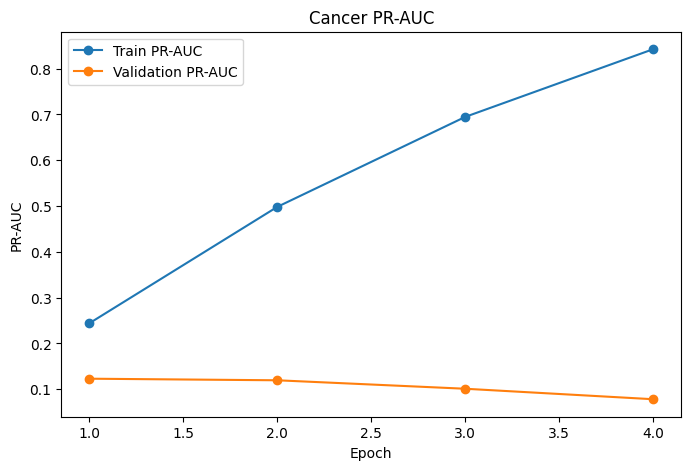

In [37]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    history_df["epoch"],
    history_df["train_pr_auc"],
    marker="o",
    label="Train PR-AUC"
)

ax.plot(
    history_df["epoch"],
    history_df["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC"
)

ax.set_title(
    "Cancer PR-AUC"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("PR-AUC")

ax.legend()

plt.show()

# 32. Load Best Checkpoint

In [38]:
model.load_state_dict(
    torch.load(
        BEST_CHECKPOINT,
        map_location=device
    )
)

model.eval()

print(
    "Best checkpoint loaded."
)

Best checkpoint loaded.


# 33. Prediction Function

Generate predictions for:

- Cancer probability
- Density
- View
- Laterality

In [39]:
def predict_loader(
    model,
    loader
):

    model.eval()

    cancer_probs = []
    cancer_targets = []

    density_preds = []
    view_preds = []
    laterality_preds = []

    patient_ids = []
    image_ids = []
    views = []
    lateralities = []

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(
                device
            )

            outputs = model(
                images
            )

            probs = torch.sigmoid(
                outputs["cancer"]
                .view(-1)
            )

            cancer_probs.extend(
                probs.cpu().numpy()
            )

            cancer_targets.extend(
                batch["cancer"].numpy()
            )

            density_preds.extend(
                outputs["density"]
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            view_preds.extend(
                outputs["view"]
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            laterality_preds.extend(
                outputs["laterality"]
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

            patient_ids.extend(
                batch["patient_id"]
            )

            image_ids.extend(
                batch["image_id"]
            )

            views.extend(
                batch["view_raw"]
            )

            lateralities.extend(
                batch["laterality_raw"]
            )

    return pd.DataFrame({

        "patient_id":
            patient_ids,

        "image_id":
            image_ids,

        "cancer":
            cancer_targets,

        "cancer_probability":
            cancer_probs,

        "density_pred":
            density_preds,

        "view_pred":
            view_preds,

        "laterality_pred":
            laterality_preds,

        "view":
            views,

        "laterality":
            lateralities
    })

# 34. Cancer Threshold Tuning

Select the Cancer classification threshold using the validation set.

The test set will NOT be used for threshold selection.

In [40]:
val_predictions = predict_loader(
    model,
    val_loader
)

threshold_results = []

for threshold in np.arange(
    0.05,
    0.96,
    0.01
):

    preds = (
        val_predictions[
            "cancer_probability"
        ] >= threshold
    ).astype(int)

    precision = precision_score(
        val_predictions["cancer"],
        preds,
        zero_division=0
    )

    recall = recall_score(
        val_predictions["cancer"],
        preds,
        zero_division=0
    )

    f1 = f1_score(
        val_predictions["cancer"],
        preds,
        zero_division=0
    )

    threshold_results.append({

        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = (
    threshold_df
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]
)

BEST_THRESHOLD = float(
    best_threshold_row["threshold"]
)

display(
    threshold_df
    .sort_values(
        "f1",
        ascending=False
    )
    .head(10)
)

print(
    "Best Threshold:",
    BEST_THRESHOLD
)

,threshold,precision,recall,f1
88,0.93,0.142857,0.177778,0.158416
89,0.94,0.145540,0.172222,0.157761
87,0.92,0.139130,0.177778,0.156098
86,0.91,0.132231,0.177778,0.151659
85,0.90,0.128514,0.177778,0.149184
90,0.95,0.142857,0.155556,0.148936
84,0.89,0.125490,0.177778,0.147126
81,0.86,0.118467,0.188889,0.145610
83,0.88,0.122137,0.177778,0.144796
82,0.87,0.119565,0.183333,0.144737


Best Threshold: 0.9300000000000002


# 35. Final Test Evaluation

Evaluate the selected checkpoint exactly once on the held-out test set.

The threshold was selected using Validation only.

In [41]:
test_predictions = predict_loader(
    model,
    test_loader
)

test_pred = (
    test_predictions[
        "cancer_probability"
    ] >= BEST_THRESHOLD
).astype(int)

y_test = test_predictions[
    "cancer"
].astype(int)

test_probability = test_predictions[
    "cancer_probability"
]

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probability
)

test_pr_auc = average_precision_score(
    y_test,
    test_probability
)

print(
    f"Threshold: {BEST_THRESHOLD:.2f}"
)

print(
    f"Accuracy: {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall: {test_recall:.4f}"
)

print(
    f"F1: {test_f1:.4f}"
)

print(
    f"ROC-AUC: {test_roc_auc:.4f}"
)

print(
    f"PR-AUC: {test_pr_auc:.4f}"
)

Threshold: 0.93
Accuracy: 0.9631
Precision: 0.1981
Recall: 0.2316
F1: 0.2135
ROC-AUC: 0.7403
PR-AUC: 0.1501


# 36. Confusion Matrix

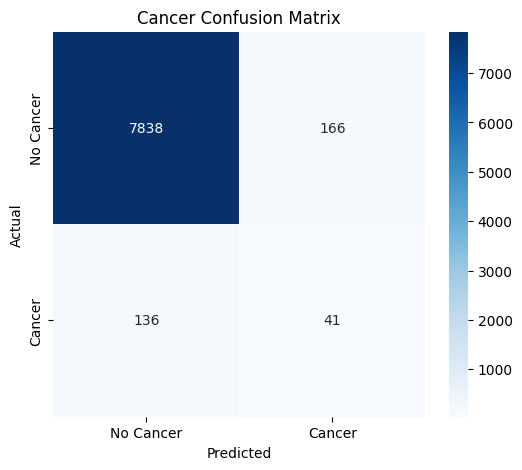

In [43]:
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Cancer",
        "Cancer"
    ],
    yticklabels=[
        "No Cancer",
        "Cancer"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Cancer Confusion Matrix")

plt.show()

# 37. Classification Report

In [44]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "No Cancer",
            "Cancer"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   No Cancer       0.98      0.98      0.98      8004
      Cancer       0.20      0.23      0.21       177

    accuracy                           0.96      8181
   macro avg       0.59      0.61      0.60      8181
weighted avg       0.97      0.96      0.96      8181



# 38. Breast-Level Cancer Aggregation

Aggregate the image-level Cancer probabilities for each:

- Patient
- Laterality

CC and MLO views from the same breast are treated as complementary
views.

The maximum probability is used as the breast-level risk score.

In [45]:
breast_df = test_predictions.copy()

# Keep standard screening views when available.
breast_df = breast_df[
    breast_df["view"].isin(
        ["CC", "MLO"]
    )
].copy()

breast_level = (
    breast_df
    .groupby(
        [
            "patient_id",
            "laterality"
        ],
        as_index=False
    )
    .agg(
        cancer_probability=(
            "cancer_probability",
            "max"
        ),
        cancer=(
            "cancer",
            "max"
        ),
        n_views=(
            "image_id",
            "count"
        )
    )
)

breast_level.head()

,patient_id,laterality,cancer_probability,cancer,n_views
0,10050,L,0.384662,0.0,2
1,10050,R,0.126925,0.0,2
2,10095,L,0.405106,0.0,2
3,10095,R,0.128596,0.0,2
4,10124,L,0.985883,0.0,2


# 39. Breast-Level Evaluation

In [46]:
breast_pred = (
    breast_level[
        "cancer_probability"
    ] >= BEST_THRESHOLD
).astype(int)

breast_true = breast_level[
    "cancer"
].astype(int)

breast_accuracy = accuracy_score(
    breast_true,
    breast_pred
)

breast_precision = precision_score(
    breast_true,
    breast_pred,
    zero_division=0
)

breast_recall = recall_score(
    breast_true,
    breast_pred,
    zero_division=0
)

breast_f1 = f1_score(
    breast_true,
    breast_pred,
    zero_division=0
)

breast_roc_auc = roc_auc_score(
    breast_true,
    breast_level[
        "cancer_probability"
    ]
)

breast_pr_auc = average_precision_score(
    breast_true,
    breast_level[
        "cancer_probability"
    ]
)

print(
    f"Breast-Level Accuracy: "
    f"{breast_accuracy:.4f}"
)

print(
    f"Breast-Level Precision: "
    f"{breast_precision:.4f}"
)

print(
    f"Breast-Level Recall: "
    f"{breast_recall:.4f}"
)

print(
    f"Breast-Level F1: "
    f"{breast_f1:.4f}"
)

print(
    f"Breast-Level ROC-AUC: "
    f"{breast_roc_auc:.4f}"
)

print(
    f"Breast-Level PR-AUC: "
    f"{breast_pr_auc:.4f}"
)

Breast-Level Accuracy: 0.9502
Breast-Level Precision: 0.1829
Breast-Level Recall: 0.4054
Breast-Level F1: 0.2521
Breast-Level ROC-AUC: 0.7928
Breast-Level PR-AUC: 0.1927


# 40. Grad-CAM Explainability

Generate a Grad-CAM heatmap from the Cancer head.

The highlighted region is a model-derived Point of Interest (POI),
not a confirmed lesion localization.

In [47]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 2.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.2 MB/s eta 0:00:00:00:0100:01


In [48]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 41. Grad-CAM Model Wrapper

In [49]:
class CancerGradCAMWrapper(
    nn.Module
):

    def __init__(self, model):

        super().__init__()

        self.model = model

    def forward(self, x):

        return self.model(
            x
        )["cancer"]

# 42. Generate Cancer Grad-CAM

In [50]:
gradcam_model = CancerGradCAMWrapper(
    model
)

target_layers = [
    model.backbone.features[-1]
]

cam = GradCAM(
    model=gradcam_model,
    target_layers=target_layers
)

# 43. Extract Model-Derived POI

In [51]:
def get_poi_box(
    grayscale_cam,
    original_size,
    percentile=85
):

    cam_map = grayscale_cam

    threshold = max(
        0.55,
        np.percentile(
            cam_map,
            percentile
        )
    )

    ys, xs = np.where(
        cam_map >= threshold
    )

    if len(xs) == 0:
        return None

    original_w, original_h = (
        original_size
    )

    cam_image = Image.fromarray(
        np.uint8(
            cam_map * 255
        )
    ).resize(
        (original_w, original_h)
    )

    cam_resized = (
        np.asarray(
            cam_image
        ) / 255.0
    )

    ys, xs = np.where(
        cam_resized >= threshold
    )

    if len(xs) == 0:
        return None

    x1 = int(xs.min())
    x2 = int(xs.max())

    y1 = int(ys.min())
    y2 = int(ys.max())

    return (
        x1,
        y1,
        x2,
        y2
    )

# 44. Test Grad-CAM on a Mammogram

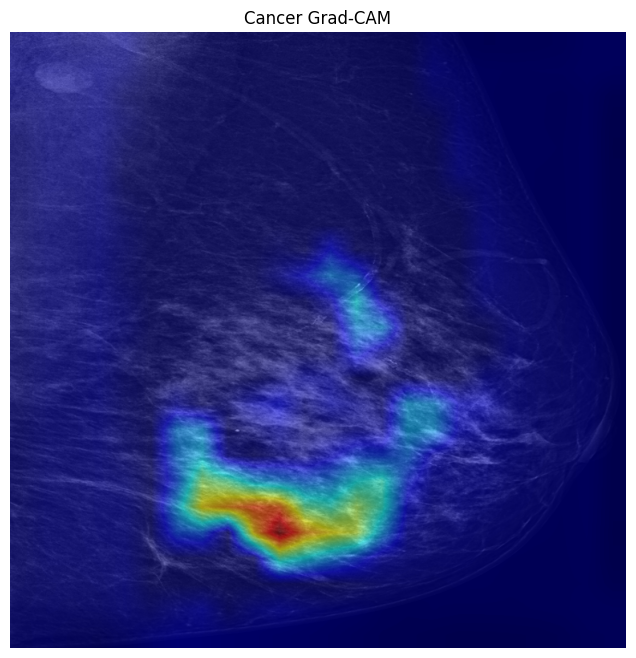

POI Box: (200, 947, 375, 1082)


In [53]:
sample_row = test_df.iloc[0]

# =========================
# Load Original Image
# =========================

original_image = Image.open(
    sample_row["image_path"]
).convert("RGB")


# =========================
# Prepare Input
# =========================

input_tensor = val_test_transform(
    original_image
).unsqueeze(0).to(device)


# =========================
# Generate Grad-CAM
# =========================

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[
        ClassifierOutputTarget(0)
    ]
)[0]


# =========================
# Get POI Box
# =========================

poi_box = get_poi_box(
    grayscale_cam,
    original_image.size
)


# =========================
# Resize Image for Grad-CAM
# =========================

cam_image = original_image.resize(
    (IMAGE_SIZE, IMAGE_SIZE)
)

rgb_image = np.asarray(
    cam_image
).astype(np.float32) / 255.0


# =========================
# Create Grad-CAM Visualization
# =========================

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)


# =========================
# Display
# =========================

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    visualization
)

plt.axis("off")

plt.title(
    "Cancer Grad-CAM"
)

plt.show()


# =========================
# POI Box
# =========================

print(
    "POI Box:",
    poi_box
)

# 45. POI Bounding Box

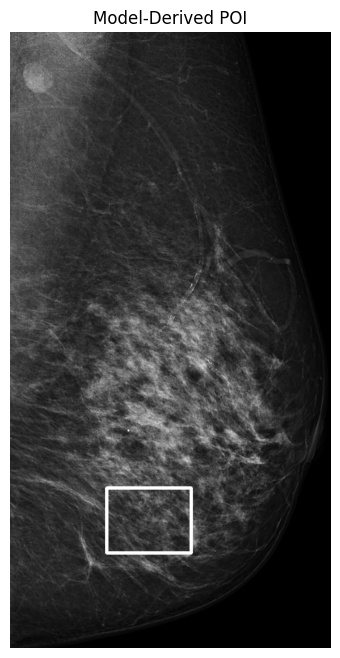

In [54]:
import cv2

poi_image = np.asarray(
    original_image
    .convert("RGB")
).copy()

if poi_box is not None:

    x1, y1, x2, y2 = poi_box

    cv2.rectangle(
        poi_image,
        (x1, y1),
        (x2, y2),
        (255, 255, 255),
        5
    )

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    poi_image
)

plt.axis("off")

plt.title(
    "Model-Derived POI"
)

plt.show()

# 46. Auxiliary Task Evaluation

Evaluate:

- Density
- View
- Laterality

on the held-out test set.

In [55]:
density_true = []

density_pred = []

view_true = []

view_pred = []

laterality_true = []

laterality_pred = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        images = batch["image"].to(
            device
        )

        outputs = model(
            images
        )

        density_mask = (
            batch["density"] != -1
        )

        if density_mask.any():

            density_true.extend(
                batch["density"]
                [density_mask]
                .numpy()
            )

            density_pred.extend(
                outputs["density"]
                [density_mask.to(device)]
                .argmax(dim=1)
                .cpu()
                .numpy()
            )

        view_true.extend(
            batch["view"].numpy()
        )

        view_pred.extend(
            outputs["view"]
            .argmax(dim=1)
            .cpu()
            .numpy()
        )

        laterality_true.extend(
            batch["laterality"].numpy()
        )

        laterality_pred.extend(
            outputs["laterality"]
            .argmax(dim=1)
            .cpu()
            .numpy()
        )

In [56]:
print(
    "Density Accuracy:",
    accuracy_score(
        density_true,
        density_pred
    )
)

print(
    "View Accuracy:",
    accuracy_score(
        view_true,
        view_pred
    )
)

print(
    "Laterality Accuracy:",
    accuracy_score(
        laterality_true,
        laterality_pred
    )
)

Density Accuracy: 0.7271895723759433
View Accuracy: 0.9816648331499817
Laterality Accuracy: 0.8069918102921403


# 47. Save Final Deployment Artifacts

Save:

- Best model checkpoint
- Configuration
- Label encoders
- Training history

These files will be used by the Streamlit application.

In [58]:
import json
import joblib

# =========================
# Deployment Directory
# =========================

deployment_dir = Path(
    "/kaggle/working/"
    "breast_cancer_768_deployment"
)

deployment_dir.mkdir(
    parents=True,
    exist_ok=True
)


# =========================
# Load BEST Model
# =========================

model.load_state_dict(
    torch.load(
        BEST_CHECKPOINT,
        map_location=device
    )
)

model.eval()


# =========================
# Save BEST Model
# =========================

final_model_path = (
    deployment_dir /
    "breast_cancer_model_768.pth"
)

torch.save(
    model.state_dict(),
    final_model_path
)


# =========================
# Configuration
# =========================

config = {

    "model_name":
        "MultiTaskEfficientNetB0",

    "backbone":
        "EfficientNet-B0",

    "image_size":
        IMAGE_SIZE,

    "mean":
        IMAGENET_MEAN,

    "std":
        IMAGENET_STD,

    "cancer_threshold":
        BEST_THRESHOLD,

    "positive_sampling_ratio":
        TARGET_POSITIVE_RATIO,

    "tasks": {

        "cancer":
            "binary_classification",

        "density":
            "multiclass_classification",

        "view":
            "multiclass_classification",

        "laterality":
            "multiclass_classification"
    },

    "gradcam_target":
        "cancer",

    "horizontal_flip":
        False,

    "breast_level_aggregation":
        "max_probability_by_patient_and_laterality"
}


# =========================
# Save Config
# =========================

with open(
    deployment_dir / "config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# =========================
# Save Label Encoders
# =========================

joblib.dump(
    label_encoders,
    deployment_dir /
    "label_encoders.pkl"
)


# =========================
# Save Training History
# =========================

history_df.to_csv(
    deployment_dir /
    "training_history.csv",
    index=False
)


# =========================
# Check Saved Files
# =========================

print("Deployment artifacts saved to:")
print(deployment_dir)

print("\nFiles:")

for file in deployment_dir.iterdir():
    print(
        file.name,
        f"({file.stat().st_size / (1024**2):.2f} MB)"
    )

Deployment artifacts saved to:
/kaggle/working/breast_cancer_768_deployment

Files:
training_history.csv (0.00 MB)
config.json (0.00 MB)
label_encoders.pkl (0.00 MB)
breast_cancer_model_768.pth (15.65 MB)


# 48. Final Model Summary

## Model

- EfficientNet-B0
- Pretrained ImageNet backbone
- 768 × 768 input
- Multi-task architecture

## Tasks

- Cancer
- Density
- View
- Laterality

## Imbalance Handling

- WeightedRandomSampler
- Target positive sampling ratio ≈ 10%
- Cancer positive class weighting

## Data Split

- Patient-level split
- No patient overlap between Train / Validation / Test

## Explainability

- Grad-CAM
- Model-derived POI

## Breast-Level Evaluation

Cancer probabilities are aggregated across mammographic views
for the same patient and laterality.

## Deployment

The final Streamlit application accepts one mammogram image and
returns:

- Cancer / No Cancer
- Cancer confidence
- Density
- View
- Laterality
- Grad-CAM
- Model-derived POI

The test set is used only for final evaluation after model and
threshold selection.

Selected Image:
/kaggle/input/rsna-breast-cancer-detection-poi-images/bc_1280_train_lut/17517_666453100.png

MODEL PREDICTION
Cancer Probability: 0.3897
Cancer Confidence: 38.97%
Threshold: 0.93
Prediction: No Cancer
Density: A
View: MLO
Laterality: L

POI Box: (131, 770, 401, 1078)


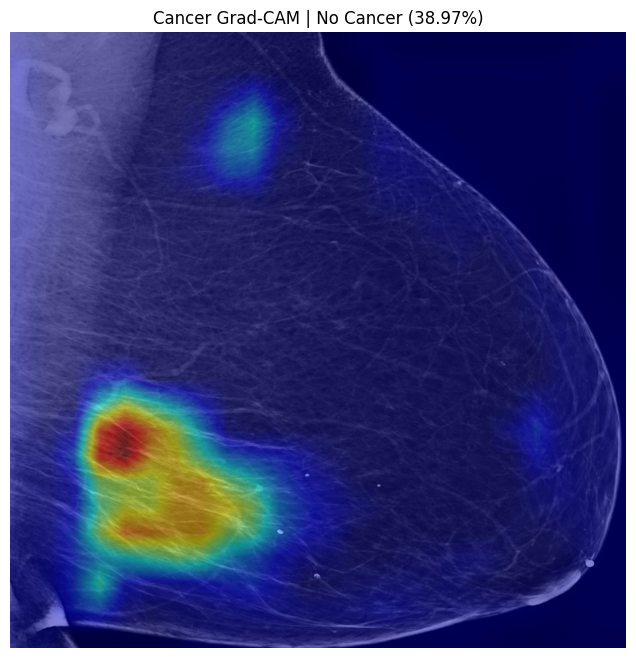


Ground Truth: No Cancer


In [61]:
# =========================================================
# Random Image Test + Cancer Prediction + Grad-CAM
# =========================================================

import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# =========================================================
# 1. Load BEST Model
# =========================================================

model.load_state_dict(
    torch.load(
        BEST_CHECKPOINT,
        map_location=device
    )
)

model.eval()


# =========================================================
# 2. Select Random Test Image
# =========================================================

sample_row = test_df.sample(
    n=1
).iloc[0]

image_path = sample_row["image_path"]

print("Selected Image:")
print(image_path)


# =========================================================
# 3. Load Image
# =========================================================

original_image = Image.open(
    image_path
).convert("RGB")


# =========================================================
# 4. Preprocess
# =========================================================

input_tensor = val_test_transform(
    original_image
).unsqueeze(0).to(device)


# =========================================================
# 5. Normal Model Prediction
# =========================================================

with torch.no_grad():

    outputs = model(
        input_tensor
    )


# =========================================================
# 6. Cancer Prediction
# =========================================================

cancer_probability = torch.sigmoid(
    outputs["cancer"].view(-1)
).item()

cancer_prediction = (
    cancer_probability >= BEST_THRESHOLD
)


# =========================================================
# 7. Auxiliary Predictions
# =========================================================

density_idx = (
    outputs["density"]
    .argmax(dim=1)
    .item()
)

view_idx = (
    outputs["view"]
    .argmax(dim=1)
    .item()
)

laterality_idx = (
    outputs["laterality"]
    .argmax(dim=1)
    .item()
)


density_label = label_encoders[
    "density"
].inverse_transform(
    [density_idx]
)[0]

view_label = label_encoders[
    "view"
].inverse_transform(
    [view_idx]
)[0]

laterality_label = label_encoders[
    "laterality"
].inverse_transform(
    [laterality_idx]
)[0]


# =========================================================
# 8. Print Results
# =========================================================

print("\n" + "=" * 50)
print("MODEL PREDICTION")
print("=" * 50)

print(
    f"Cancer Probability: "
    f"{cancer_probability:.4f}"
)

print(
    f"Cancer Confidence: "
    f"{cancer_probability * 100:.2f}%"
)

print(
    f"Threshold: "
    f"{BEST_THRESHOLD:.2f}"
)

print(
    f"Prediction: "
    f"{'Cancer' if cancer_prediction else 'No Cancer'}"
)

print(
    f"Density: {density_label}"
)

print(
    f"View: {view_label}"
)

print(
    f"Laterality: {laterality_label}"
)

print("=" * 50)


# =========================================================
# 9. Grad-CAM Wrapper
# =========================================================

class CancerOutputWrapper(torch.nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        outputs = self.model(x)

        # Return ONLY cancer logits
        return outputs["cancer"]


cam_model = CancerOutputWrapper(
    model
)


# =========================================================
# 10. Grad-CAM Target Layer
# =========================================================

target_layers = [
    cam_model.model.backbone.features[-1]
]


cam = GradCAM(
    model=cam_model,
    target_layers=target_layers
)


# =========================================================
# 11. Generate Grad-CAM
# =========================================================

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[
        ClassifierOutputTarget(0)
    ]
)[0]


# =========================================================
# 12. POI Box
# =========================================================

poi_box = get_poi_box(
    grayscale_cam,
    original_image.size
)

print(
    "\nPOI Box:",
    poi_box
)


# =========================================================
# 13. Prepare Image
# =========================================================

cam_image = original_image.resize(
    (IMAGE_SIZE, IMAGE_SIZE)
)

rgb_image = (
    np.asarray(cam_image)
    .astype(np.float32)
    / 255.0
)


# =========================================================
# 14. Grad-CAM Visualization
# =========================================================

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)


# =========================================================
# 15. Display Grad-CAM
# =========================================================

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    visualization
)

plt.axis("off")

plt.title(
    f"Cancer Grad-CAM | "
    f"{'Cancer' if cancer_prediction else 'No Cancer'} "
    f"({cancer_probability * 100:.2f}%)"
)

plt.show()


# =========================================================
# 16. Ground Truth
# =========================================================

print(
    "\nGround Truth:",
    "Cancer"
    if int(sample_row["cancer"]) == 1
    else "No Cancer"
)

Selected Cancer Image:
/kaggle/input/rsna-breast-cancer-detection-poi-images/bc_1280_train_lut/14962_1306633485.png
Original Size: (605, 1280)


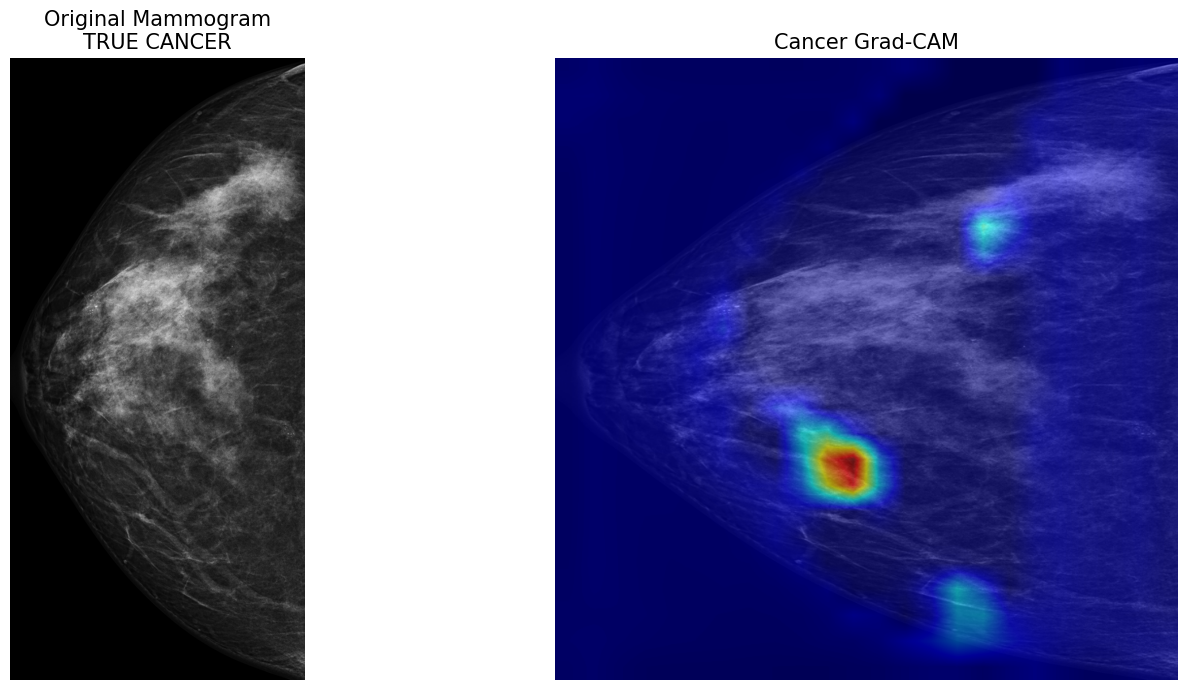


                    MODEL RESULTS
Ground Truth       : Cancer
Cancer Probability : 0.1033
Cancer Confidence  : 10.33%
Threshold          : 0.93
Prediction         : No Cancer
Density            : C
View               : CC
Laterality         : R


In [62]:
# =========================================================
# Test a TRUE CANCER image + Original Image + Grad-CAM
# =========================================================

import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# =========================================================
# 1. Load BEST Model
# =========================================================

model.load_state_dict(
    torch.load(BEST_CHECKPOINT, map_location=device)
)

model.eval()


# =========================================================
# 2. Select a TRUE CANCER image from Test Set
# =========================================================

cancer_test_df = test_df[
    test_df["cancer"] == 1
].reset_index(drop=True)

sample_row = cancer_test_df.sample(
    n=1,
    random_state=42
).iloc[0]

image_path = sample_row["image_path"]

print("Selected Cancer Image:")
print(image_path)


# =========================================================
# 3. Load Original Image
# =========================================================

original_image = Image.open(
    image_path
).convert("RGB")

print(
    "Original Size:",
    original_image.size
)


# =========================================================
# 4. Preprocess Image
# =========================================================

input_tensor = val_test_transform(
    original_image
).unsqueeze(0).to(device)


# =========================================================
# 5. Model Prediction
# =========================================================

with torch.no_grad():

    outputs = model(input_tensor)

    cancer_probability = torch.sigmoid(
        outputs["cancer"]
    ).item()

    density_prediction = torch.argmax(
        outputs["density"],
        dim=1
    ).item()

    view_prediction = torch.argmax(
        outputs["view"],
        dim=1
    ).item()

    laterality_prediction = torch.argmax(
        outputs["laterality"],
        dim=1
    ).item()


# =========================================================
# 6. Decode Auxiliary Predictions
# =========================================================

density_label = label_encoders["density"].inverse_transform(
    [density_prediction]
)[0]

view_label = label_encoders["view"].inverse_transform(
    [view_prediction]
)[0]

laterality_label = label_encoders["laterality"].inverse_transform(
    [laterality_prediction]
)[0]


# =========================================================
# 7. Cancer Prediction
# =========================================================

cancer_prediction = (
    cancer_probability >= BEST_THRESHOLD
)


# =========================================================
# 8. Grad-CAM Wrapper
# =========================================================

class CancerOutputWrapper(torch.nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        outputs = self.model(x)

        return outputs["cancer"]


cam_model = CancerOutputWrapper(model)


# =========================================================
# 9. Grad-CAM
# =========================================================

target_layers = [
    cam_model.model.backbone.features[-1]
]

cam = GradCAM(
    model=cam_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[
        ClassifierOutputTarget(0)
    ]
)[0]


# =========================================================
# 10. Create Grad-CAM Visualization
# =========================================================

cam_image = original_image.resize(
    (IMAGE_SIZE, IMAGE_SIZE)
)

rgb_image = (
    np.asarray(cam_image)
    .astype(np.float32)
    / 255.0
)

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)


# =========================================================
# 11. Display Original + Grad-CAM
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)


# Original
axes[0].imshow(
    original_image
)

axes[0].axis("off")

axes[0].set_title(
    "Original Mammogram\nTRUE CANCER",
    fontsize=15
)


# Grad-CAM
axes[1].imshow(
    visualization
)

axes[1].axis("off")

axes[1].set_title(
    "Cancer Grad-CAM",
    fontsize=15
)


plt.tight_layout()
plt.show()


# =========================================================
# 12. Print Results
# =========================================================

print("\n" + "=" * 65)
print("                    MODEL RESULTS")
print("=" * 65)

print(
    f"Ground Truth       : Cancer"
)

print(
    f"Cancer Probability : "
    f"{cancer_probability:.4f}"
)

print(
    f"Cancer Confidence  : "
    f"{cancer_probability * 100:.2f}%"
)

print(
    f"Threshold          : "
    f"{BEST_THRESHOLD:.2f}"
)

print(
    f"Prediction         : "
    f"{'Cancer' if cancer_prediction else 'No Cancer'}"
)

print(
    f"Density            : "
    f"{density_label}"
)

print(
    f"View               : "
    f"{view_label}"
)

print(
    f"Laterality         : "
    f"{laterality_label}"
)

print("=" * 65)

POI Box: (255, 798, 47, 97)


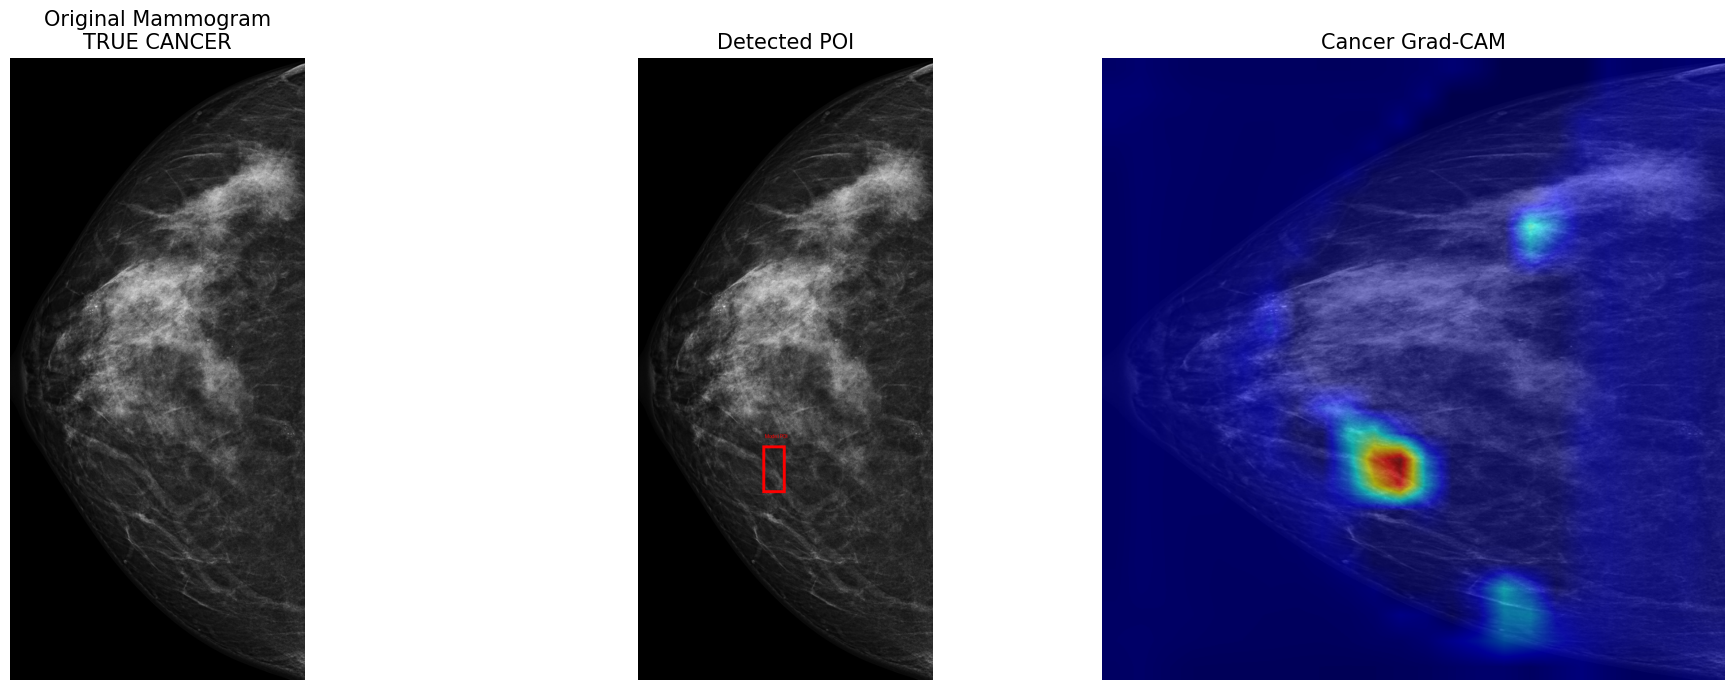


                    MODEL RESULTS
Ground Truth       : Cancer
Cancer Probability : 0.1033
Cancer Confidence  : 10.33%
Threshold          : 0.93
Prediction         : No Cancer
Density            : C
View               : CC
Laterality         : R
POI Box            : (255, 798, 47, 97)


In [63]:
# =========================================================
# 9. Grad-CAM + POI Bounding Box
# =========================================================

target_layers = [
    cam_model.model.backbone.features[-1]
]

cam = GradCAM(
    model=cam_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(0)]
)[0]


# =========================================================
# 10. Find POI from Grad-CAM
# =========================================================

def get_poi_box(grayscale_cam, image_size, threshold_ratio=0.60):

    h, w = grayscale_cam.shape

    # Threshold relative to maximum activation
    threshold = grayscale_cam.max() * threshold_ratio

    mask = grayscale_cam >= threshold

    # Find activated pixels
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return None

    x1 = int(xs.min())
    x2 = int(xs.max())
    y1 = int(ys.min())
    y2 = int(ys.max())

    # Convert CAM coordinates → original image coordinates
    original_w, original_h = image_size

    scale_x = original_w / w
    scale_y = original_h / h

    x1 = int(x1 * scale_x)
    x2 = int(x2 * scale_x)
    y1 = int(y1 * scale_y)
    y2 = int(y2 * scale_y)

    return (
        x1,
        y1,
        x2 - x1,
        y2 - y1
    )


poi_box = get_poi_box(
    grayscale_cam,
    original_image.size,
    threshold_ratio=0.60
)

print("POI Box:", poi_box)


# =========================================================
# 11. Draw POI Box on Original Image
# =========================================================

from PIL import ImageDraw

boxed_image = original_image.copy()

draw = ImageDraw.Draw(boxed_image)

if poi_box is not None:

    x, y, box_w, box_h = poi_box

    draw.rectangle(
        [
            x,
            y,
            x + box_w,
            y + box_h
        ],
        outline="red",
        width=6
    )

    # Label
    draw.text(
        (x + 5, max(5, y - 25)),
        "Model POI",
        fill="red"
    )


# =========================================================
# 12. Create Grad-CAM Visualization
# =========================================================

cam_image = original_image.resize(
    (IMAGE_SIZE, IMAGE_SIZE)
)

rgb_image = (
    np.asarray(cam_image)
    .astype(np.float32)
    / 255.0
)

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)


# =========================================================
# 13. Display
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)


# -------------------------
# Original
# -------------------------

axes[0].imshow(original_image)

axes[0].axis("off")

axes[0].set_title(
    "Original Mammogram\nTRUE CANCER",
    fontsize=15
)


# -------------------------
# Original + POI Box
# -------------------------

axes[1].imshow(boxed_image)

axes[1].axis("off")

axes[1].set_title(
    "Detected POI",
    fontsize=15
)


# -------------------------
# Grad-CAM
# -------------------------

axes[2].imshow(visualization)

axes[2].axis("off")

axes[2].set_title(
    "Cancer Grad-CAM",
    fontsize=15
)


plt.tight_layout()
plt.show()


# =========================================================
# 14. Results
# =========================================================

print("\n" + "=" * 65)
print("                    MODEL RESULTS")
print("=" * 65)

print(f"Ground Truth       : Cancer")
print(f"Cancer Probability : {cancer_probability:.4f}")
print(f"Cancer Confidence  : {cancer_probability * 100:.2f}%")
print(f"Threshold          : {BEST_THRESHOLD:.2f}")

print(
    f"Prediction         : "
    f"{'Cancer' if cancer_prediction else 'No Cancer'}"
)

print(f"Density            : {density_label}")
print(f"View               : {view_label}")
print(f"Laterality         : {laterality_label}")
print(f"POI Box            : {poi_box}")

print("=" * 65)